# Probe Analysis

Train logistic-regression probes on JudgementLM attention activations and
evaluate at predicting valid/invalid labels.

**Labels** are the union of:
- `judgement_combined` — majority-vote LLM judge output
- `matching_status`    — whether the extraction matches a ground-truth row

**Analyses**
1. Baseline: raw judge model accuracy
2. Single-head selection: score every (layer, head) pair; visualise heatmap,
   PCA, calibration, probability distribution
3. Iterative greedy selection: sequentially add the head with the highest
   marginal contribution; same visualisations per iteration

In [77]:
import sys
from pathlib import Path
%load_ext autoreload
%autoreload 2

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))
sys.path.insert(0, str(REPO_ROOT / 'experiments'))
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from analysis.loaders import (
    load_activations, load_layer_outputs, load_combined_judgements,
    load_extraction, load_ground_truth, cached_match,
)
from analysis.plots import calibration_curve, probability_distribution
from analysis.metrics import recovery_rate, hallucination_rate
from scholarlm.utils.probe import (
    get_head_features, grouped_kfold_split, grouped_holdout_split,
    train_probe, eval_probe, eval_probe_detailed,
)
from scholarlm.utils.calibration import reliability_diagram_data
from scholarlm.utils.unit_conversion import apply_unit_conversion
from experiments.run_extraction import load_dataset_config
import paths


# ── Publication style ──
mpl.rcParams.update({
    # Fonts
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,  # set True if you have a TeX install and want perfect font matching

    # Font sizes — figure text should be ≤ body text (10pt)
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.title_fontsize": 9,

    # Axes/ticks
    "axes.linewidth": 0.6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.size": 1.5,
    "ytick.minor.size": 1.5,

    # Lines
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Legend
    "legend.frameon": False,
    "legend.borderpad": 0.3,
    "legend.columnspacing": 1.0,
    "legend.handletextpad": 0.5,

    # Figure — save as PDF vector, not PNG
    "figure.dpi": 150,        # display
    "savefig.dpi": 300,       # raster fallback only
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,       # TrueType, editable/searchable — required by many venues
    "ps.fonttype": 42,
})

FIGURES_DIR = "../figures/probe/"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load + Prepare data

In [19]:
DATASET          = 'pond'
EXTRACTION_MODEL = 'gemma-3-27b'
EXTRACTION_DATE  = '2026_04_19'
JUDGE_MODEL      = 'llama-3.1-8b'
JUDGE_DATE       = '2026_04_22'
TOP_K            = 5   # number of greedy iterations
N_FOLDS          = 5

activations = load_activations(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE, JUDGE_MODEL, JUDGE_DATE)
layer_outputs = load_layer_outputs(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE, JUDGE_MODEL, JUDGE_DATE)
judgements  = load_combined_judgements(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE)
judged_df   = pd.DataFrame(judgements)
measurement_ids = judged_df['measurement_id']

config          = load_dataset_config(DATASET)
records         = load_extraction(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE)
extraction_df   = pd.DataFrame(records)
extraction_df   = apply_unit_conversion(extraction_df, config.unit_conversion_table)
ground_truth_df = load_ground_truth(config)

print(f'Activations:  {len(activations.files)} entries')
print(f'Judgements:   {len(judged_df)} records')
print(f'Extraction:   {len(extraction_df)} records')
print(f'Ground truth: {len(ground_truth_df)} records')

Activations:  11768 entries
Judgements:   11768 records
Extraction:   11768 records
Ground truth: 3410 records


In [ ]:
# Load ground-truth matching from cache (produced by extraction_analysis.ipynb)
if 'pond' in DATASET:
    STRICT_MATCHING = {'document_id': 'document_id', 'attribute': 'attribute', 'value': 'converted_value'}
    FUZZY_MATCHING  = {'name': 'name', 'location': 'location', 'ecosystem': 'ecosystem'}
elif 'nfix' in DATASET:
    extraction_df['attribute'] = extraction_df['attribute'].map({'nfix_rate_areal': 'nfix_rate', 'nfix_rate_volumetric': 'nfix_rate', 'nfix_rate_mass': 'nfix_rate', 'nfix_rate': 'nfix_rate'})
    STRICT_MATCHING = {'document_id': 'document_id', 'attribute': 'attribute', 'value': 'converted_value'}
    FUZZY_MATCHING  = {'name': 'name', 'site_type': 'site_type'}
else:
    raise ValueError("Dataset not recognized.")


cache_path = paths.extraction(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE) / 'match_cache.pkl'
#cache_path = None

matching, edges, weights = cached_match(
    ground_truth_df, extraction_df,
    strict_matching=STRICT_MATCHING,
    fuzzy_matching=FUZZY_MATCHING,
    fuzzy_threshold=0.0,
    cache_path=cache_path,
)

THRESHOLD = 1/3
judgement_col = "judgement_combined"

ex_edge_exists = np.zeros(len(extraction_df), dtype = bool)
for i, (gt_idx, ex_idx) in enumerate(edges):
    if weights[i] > THRESHOLD:
        ex_edge_exists[ex_idx] = True

jlabels = judged_df[judgement_col].to_numpy(dtype = bool)
labels = jlabels | ex_edge_exists

recovery = recovery_rate(
    extraction_df = extraction_df,
    ground_truth_df = ground_truth_df,
    strict_matching = STRICT_MATCHING,
    fuzzy_matching = FUZZY_MATCHING,
    fuzzy_threshold = THRESHOLD,
    cache_path = cache_path,
)

hallucination = hallucination_rate(
    extraction_df = extraction_df,
    ground_truth_df = ground_truth_df,
    judged_df = judged_df,
    strict_matching = STRICT_MATCHING,
    fuzzy_matching = FUZZY_MATCHING,
    fuzzy_threshold = THRESHOLD,
    cache_path = cache_path,
    label_col = judgement_col
)

print("Recovery: ", recovery)
print("Hallucination: ", hallucination)

In [26]:
# ── Global train / calibration / test split ──────────────────────────────────
# These three main pools are entirely separate from one another (and come from distinct papers). 
# train_idx → data points used for training the final probe
# cal_idx  → data points used for re-calibrating the final probe after training
# test_idx → data points used for testing the final trained and re-calibrated probe
# cv_idx → Union of train and cal idx, used for head selection (5-fold CV)

groups = extraction_df["document_id"]

train_idx, cal_idx, test_idx = grouped_holdout_split(
    groups, train_frac=0.6, cal_frac=0.2, random_state=42
)
cv_idx = np.concatenate((train_idx, cal_idx))
labels_cv = labels[cv_idx]
groups_cv = groups[cv_idx]
kfold_cv = [(train_idx, test_idx) for train_idx, test_idx in grouped_kfold_split(groups_cv, n_splits=5, random_state = 42)]

print(f'Global split (total n={len(labels)}):')
print(f'  Train set : {len(train_idx):4d} ({len(train_idx)/len(labels):.1%})  pos={labels[train_idx].mean():.2%}')
print(f'  Cal set : {len(cal_idx):4d} ({len(cal_idx)/len(labels):.1%})  pos={labels[cal_idx].mean():.2%}')
print(f'  Test set: {len(test_idx):4d} ({len(test_idx)/len(labels):.1%})  pos={labels[test_idx].mean():.2%}')

Global split (total n=11768):
  Train set : 7270 (61.8%)  pos=56.69%
  Cal set : 2380 (20.2%)  pos=63.19%
  Test set: 2118 (18.0%)  pos=66.48%


In [27]:
# Attention head data:
_arr0 = np.array(activations[str(measurement_ids[0])], dtype=np.float32)
n_layers, n_heads, head_dim = _arr0.shape
print(f'Activation shape: n_layers={n_layers}, n_heads={n_heads}, head_dim={head_dim}')
print(f'Total heads: {n_layers * n_heads}')

# Load all activations into memory (one pass) then build per-head matrices
print('Loading activations into memory...')
_all_act = {
    str(mid): np.array(activations[str(mid)], dtype=np.float32)
    for mid in measurement_ids
}

print('Building per-head feature matrices...')
head_datasets: dict[tuple[int, int], np.ndarray] = {}
for l in range(n_layers):
    for h in range(n_heads):
        head_datasets[(l, h)] = np.stack(
            [_all_act[str(mid)][l, h, :] for mid in measurement_ids], axis=0
        )
del _all_act  # free memory
print(f'Done. Each head dataset shape: {head_datasets[(0, 0)].shape}')

Activation shape: n_layers=32, n_heads=32, head_dim=128
Total heads: 1024
Loading activations into memory...
Building per-head feature matrices...
Done. Each head dataset shape: (11768, 128)


In [28]:
# Layer output data:
_arr0_lo = np.array(layer_outputs[str(measurement_ids[0])], dtype=np.float32)
n_layers_lo, lo_dim = _arr0_lo.shape
print(f'Layer output shape: n_layers={n_layers_lo}, dim={lo_dim}')

# Load all layer outputs into memory (one pass) then build per-layer matrices
print('Loading layer outputs into memory...')
_all_lo = {
    str(mid): np.array(layer_outputs[str(mid)], dtype=np.float32)
    for mid in measurement_ids
}

print('Building per-layer feature matrices...')
layer_datasets: dict[int, np.ndarray] = {}
for l in range(n_layers_lo):
    layer_datasets[l] = np.stack(
        [_all_lo[str(mid)][l, :] for mid in measurement_ids], axis=0
    )
del _all_lo  # free memory
print(f'Done. Each layer dataset shape: {layer_datasets[0].shape}')

Layer output shape: n_layers=32, dim=4096
Loading layer outputs into memory...
Building per-layer feature matrices...
Done. Each layer dataset shape: (11768, 4096)


## Baseline: Raw Judge Performance

In [51]:
judge_preds = judged_df[f'judgement_{JUDGE_MODEL}'].astype(bool).values
judge_probs = judged_df[f'judgement_p_true_{JUDGE_MODEL}'].to_numpy()

tp = int(( judge_preds[test_idx] &  labels[test_idx]).sum())
tn = int((~judge_preds[test_idx] & ~labels[test_idx]).sum())
fp = int(( judge_preds[test_idx] & ~labels[test_idx]).sum())
fn = int((~judge_preds[test_idx] &  labels[test_idx]).sum())
n  = len(labels[test_idx])

acc  = (tp + tn) / n
prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
rec  = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else float('nan')

print('Raw judge model performance (against union labels):')
print(f'  Accuracy:  {acc:.4f}')
print(f'  Precision: {prec:.4f}')
print(f'  Recall:    {rec:.4f}')
print(f'  F1:        {f1:.4f}')
print(f'  TP={tp}  TN={tn}  FP={fp}  FN={fn}')

Raw judge model performance (against union labels):
  Accuracy:  0.6808
  Precision: 0.9058
  Recall:    0.5803
  F1:        0.7074
  TP=817  TN=625  FP=85  FN=591


## 1. Attention Head Probe: single-selection

Selects a single attention head to use for probe data.

In [29]:
def cv_score(probe, X, y, kfold_cv):
    """Group k-fold CV.  All inputs must already be indexed to the CV pool.

    Returns (mean_acc, fold_accs, mean_auroc, fold_aurocs, mean_f1, fold_f1s, oof_probs).
    oof_probs is aligned to the input array (length == len(y)).
    """
    fold_accs, fold_aurocs, fold_f1s = [], [], []
    fold_test_idx, fold_probs_list = [], []

    for train_idx, test_idx in kfold_cv:
        probe.fit(X[train_idx], y[train_idx])
        y_pred = probe.predict(X[test_idx])
        y_true = y[test_idx]
        probs  = probe.predict_proba(X[test_idx])[:, 1]

        fold_accs.append(float((y_pred == y_true).mean()))

        auroc = (roc_auc_score(y_true, probs)
                 if y_true.sum() > 0 and (~y_true).sum() > 0
                 else float('nan'))
        fold_aurocs.append(auroc)

        tp   = int(( y_pred &  y_true).sum())
        fp   = int(( y_pred & ~y_true).sum())
        fn   = int((~y_pred &  y_true).sum())
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        fold_f1s.append(f1)

        fold_test_idx.extend(test_idx)
        fold_probs_list.append(probs)

    oof_probs  = np.empty(len(y))
    sort_order = np.argsort(fold_test_idx)
    oof_probs[np.array(fold_test_idx)[sort_order]] = np.concatenate(fold_probs_list)[sort_order]

    return (
        float(np.mean(fold_accs)), list(fold_accs),
        float(np.nanmean(fold_aurocs)), list(fold_aurocs),
        float(np.mean(fold_f1s)), list(fold_f1s),
        oof_probs,
    )

In [57]:
def _probe_metrics(probs, y_true, label, threshold = 0.5):
    """Print and return evaluation metrics for a set of probabilities."""
    preds = probs > threshold
    tp  = int(( preds &  y_true).sum())
    tn  = int((~preds & ~y_true).sum())
    fp  = int(( preds & ~y_true).sum())
    fn  = int((~preds &  y_true).sum())
    n   = len(y_true)
    acc  = (tp + tn) / n
    prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    rec  = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else float('nan')
    auroc = (roc_auc_score(y_true, probs)
             if y_true.sum() > 0 and (~y_true).sum() > 0 else float('nan'))
    ece  = reliability_diagram_data(probs, y_true)['ece']
    print(f'{label}:')
    print(f'  Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')
    print(f'  AUROC={auroc:.4f}  ECE={ece:.4f}')
    print(f'  TP={tp}  TN={tn}  FP={fp}  FN={fn}  n={n}')
    return probs

### Select Head

In [30]:
print(f'Scoring {n_layers * n_heads} heads on CV pool (n={len(cv_idx)})...')

attention_probe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=42,
    ))
])

head_scores_acc   = np.zeros((n_layers, n_heads))
head_scores_auroc = np.zeros((n_layers, n_heads))
head_scores_f1    = np.zeros((n_layers, n_heads))
head_fold_accs    = {}
head_fold_aurocs  = {}
head_fold_f1s     = {}
head_oof_probs    = {}  # OOF probs aligned to cv_idx (length = len(cv_idx))

for l in range(n_layers):
    for h in range(n_heads):
        X_cv = head_datasets[(l, h)][cv_idx]
        (mean_acc,   fold_accs,
         mean_auroc, fold_aurocs,
         mean_f1,    fold_f1s,
         oof_probs) = cv_score(attention_probe, X_cv, labels_cv, kfold_cv)

        head_scores_acc[l, h]    = mean_acc
        head_scores_auroc[l, h]  = mean_auroc
        head_scores_f1[l, h]     = mean_f1
        head_fold_accs[(l, h)]   = fold_accs
        head_fold_aurocs[(l, h)] = fold_aurocs
        head_fold_f1s[(l, h)]    = fold_f1s
        head_oof_probs[(l, h)]   = oof_probs
    if (l + 1) % 8 == 0:
        print(f'  Layer {l + 1}/{n_layers} done')

Scoring 1024 heads on CV pool (n=9650)...
  Layer 8/32 done
  Layer 16/32 done
  Layer 24/32 done
  Layer 32/32 done


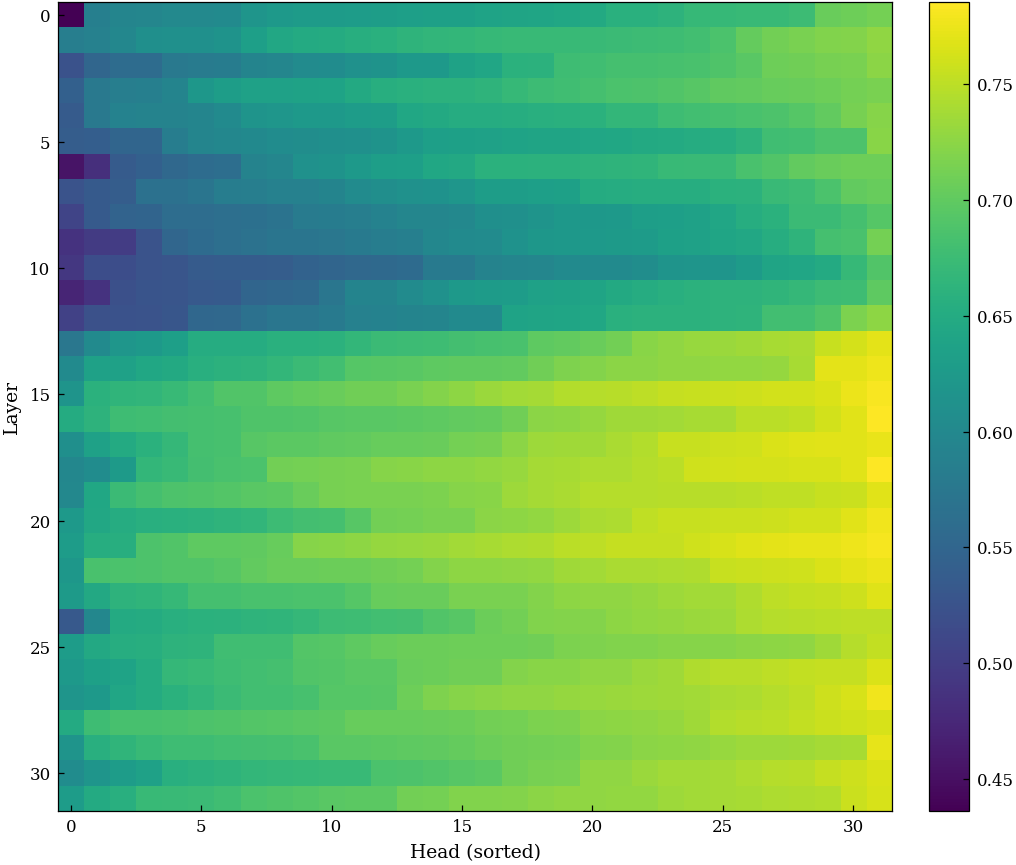

In [81]:
score_mat = head_scores_f1
fig, ax = plt.subplots(1, 1, figsize=(7,6))
im = ax.imshow(np.sort(score_mat, axis=1), cmap='viridis', aspect='auto')
ax.set_xlabel('Head (sorted)')
ax.set_ylabel('Layer')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(FIGURES_DIR + f'probe_single_heatmap_{DATASET}_e-{EXTRACTION_MODEL}_j-{JUDGE_MODEL}.pdf', bbox_inches='tight')

In [82]:
# Select best head
best_l, best_h = np.unravel_index(score_mat.argmax(), score_mat.shape)
print(f'Best head: layer={best_l}, head={best_h}')
print(f'  AUROC={head_scores_auroc[best_l, best_h]:.4f}  '
      f'F1={head_scores_f1[best_l, best_h]:.4f}  '
      f'Acc={head_scores_acc[best_l, best_h]:.4f}')

Best head: layer=16, head=11
  AUROC=0.8268  F1=0.7853  Acc=0.7681


In [95]:
k = 10  # or whatever value you want
score_mat = head_scores_f1
flat_indices = np.argsort(score_mat.flatten())[-k:][::-1]  # top k in descending order
top_k_heads = [np.unravel_index(idx, score_mat.shape) for idx in flat_indices]

print(f'Top {k} heads by F1:')
for i, (best_l, best_h) in enumerate(top_k_heads):
    print(f'  {i+1}. layer={best_l}, head={best_h}  '
          f'AUROC={head_scores_auroc[best_l, best_h]:.4f}  '
          f'F1={head_scores_f1[best_l, best_h]:.4f}  '
          f'Acc={head_scores_acc[best_l, best_h]:.4f}')

Top 10 heads by F1:
  1. layer=16, head=11  AUROC=0.8268  F1=0.7853  Acc=0.7681
  2. layer=18, head=31  AUROC=0.8179  F1=0.7847  Acc=0.7566
  3. layer=15, head=4  AUROC=0.8686  F1=0.7815  Acc=0.7588
  4. layer=21, head=0  AUROC=0.8324  F1=0.7809  Acc=0.7447
  5. layer=20, head=0  AUROC=0.8391  F1=0.7781  Acc=0.7488
  6. layer=27, head=1  AUROC=0.8191  F1=0.7774  Acc=0.7435
  7. layer=14, head=24  AUROC=0.8144  F1=0.7762  Acc=0.7532
  8. layer=21, head=7  AUROC=0.8258  F1=0.7759  Acc=0.7469
  9. layer=15, head=8  AUROC=0.8222  F1=0.7753  Acc=0.7432
  10. layer=22, head=25  AUROC=0.8150  F1=0.7751  Acc=0.7419


### Calibration + Visualization

=== Final single-head probe (L22, H25) — test set ===

Next token prediction:
  Accuracy=0.6638  Precision=0.9104  Recall=0.5483  F1=0.6844
  AUROC=0.8295  ECE=0.2463
  TP=772  TN=634  FP=76  FN=636  n=2118

Platt-calibrated next token probability:
  Accuracy=0.7724  Precision=0.7756  Recall=0.9254  F1=0.8439
  AUROC=0.8295  ECE=0.0820
  TP=1303  TN=333  FP=377  FN=105  n=2118

Probe prediction:
  Accuracy=0.7842  Precision=0.7966  Recall=0.9070  F1=0.8482
  AUROC=0.8245  ECE=0.1735
  TP=1277  TN=384  FP=326  FN=131  n=2118

Platt-calibrated probe prediction:
  Accuracy=0.7819  Precision=0.7867  Recall=0.9219  F1=0.8489
  AUROC=0.8245  ECE=0.0510
  TP=1298  TN=358  FP=352  FN=110  n=2118


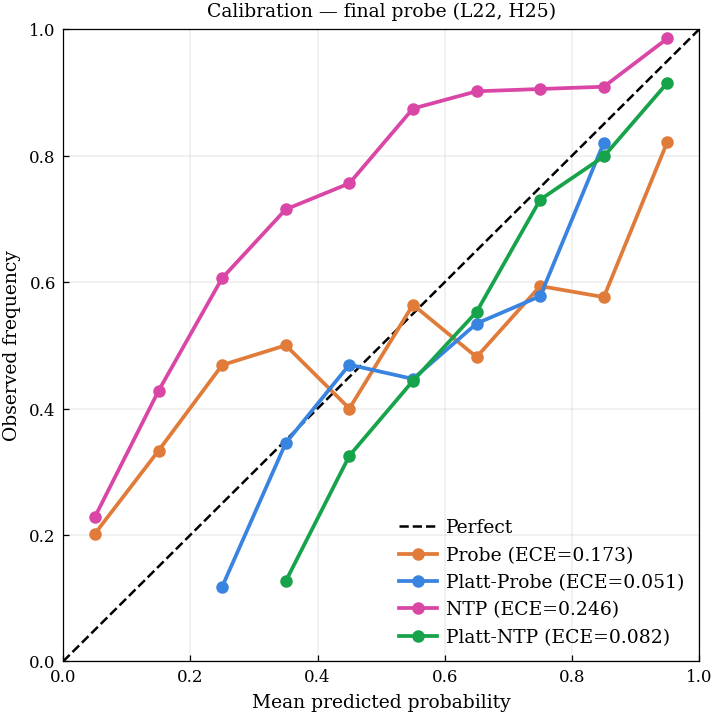

In [96]:
# ── Final Single-Head Probe: Training + Platt Scaling + Test Evaluation ───────

#X_train_s   = head_datasets[(best_l, best_h)][train_idx]
#X_cal_s  = head_datasets[(best_l, best_h)][cal_idx]
#X_test_s = head_datasets[(best_l, best_h)][test_idx]
X_train_s   = np.concatenate([head_datasets[lh][train_idx] for lh in top_k_heads], axis=1)
X_cal_s     = np.concatenate([head_datasets[lh][cal_idx] for lh in top_k_heads], axis=1)
X_test_s    = np.concatenate([head_datasets[lh][test_idx] for lh in top_k_heads], axis=1)
y_train_s, y_cal_s, y_test_s = labels[train_idx], labels[cal_idx], labels[test_idx]

# Train final probe on the CV pool
final_probe_single = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0, class_weight='balanced', solver='lbfgs',
        max_iter=1000, random_state=42,
    ))
]).fit(X_train_s, y_train_s)

# Platt scaling: 1-D logistic regression on calibration-set probabilities
raw_cal_s = final_probe_single.predict_proba(X_cal_s)[:, 1].reshape(-1, 1)
platt_single = LogisticRegression(C=1e6, solver='lbfgs', max_iter=1000).fit(raw_cal_s, y_cal_s)

# Test-set probabilities
raw_test_s = final_probe_single.predict_proba(X_test_s)[:, 1]
cal_test_s = platt_single.predict_proba(raw_test_s.reshape(-1, 1))[:, 1]

# Platt scaling for judge probabilities (calibration set only)
judge_cal_probs = judge_probs[cal_idx].reshape(-1, 1)
platt_judge = LogisticRegression(C=1e6, solver='lbfgs', max_iter=1000).fit(judge_cal_probs, y_cal_s)
judge_test_probs = judge_probs[test_idx]
cal_judge_probs = platt_judge.predict_proba(judge_test_probs.reshape(-1, 1))[:, 1]

print(f'=== Final single-head probe (L{best_l}, H{best_h}) — test set ===\n')
_probe_metrics(judge_test_probs, y_test_s, 'Next token prediction')
print()
_probe_metrics(cal_judge_probs, y_test_s, 'Platt-calibrated next token probability')
print()
_probe_metrics(raw_test_s, y_test_s, 'Probe prediction')
print()
_probe_metrics(cal_test_s, y_test_s, 'Platt-calibrated probe prediction')


# Calibration curves
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect')
for probs, label, color in [
    (raw_test_s, 'Probe', '#e07b39'),
    (cal_test_s, 'Platt-Probe', '#3984e0'),
    (judge_test_probs, 'NTP', '#d946a6'),
    (cal_judge_probs, 'Platt-NTP', '#16a34a'),
]:
    d = reliability_diagram_data(probs, y_test_s)
    valid = ~np.isnan(d['bin_accuracy'])
    ax.plot(d['bin_centers'][valid], d['bin_accuracy'][valid], 'o-',
            color=color, lw=1.8, ms=5, label=f"{label} (ECE={d['ece']:.3f})")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed frequency')
ax.set_title(f'Calibration — final probe (L{best_l}, H{best_h})')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURES_DIR + f'probe_single_calibration_{DATASET}_e-{EXTRACTION_MODEL}_j-{JUDGE_MODEL}.pdf', bbox_inches='tight')

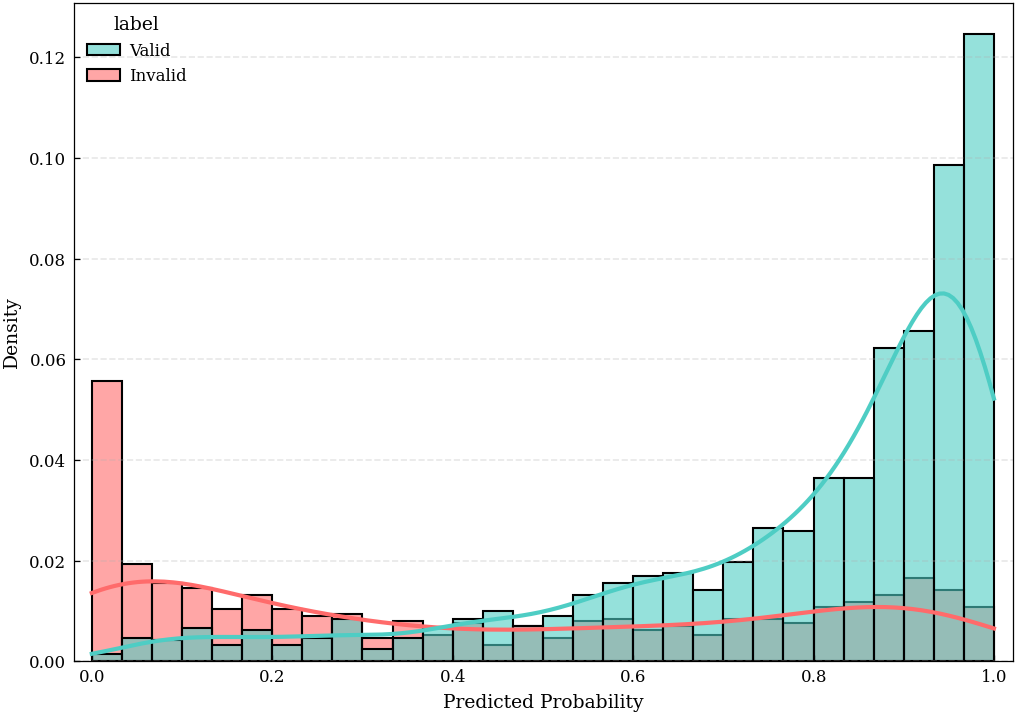

In [78]:
_df_multi = pd.DataFrame({'prob': raw_test_s, 'label': y_test_s})
_df_multi['label'] = _df_multi['label'].map({True: 'Valid', False: 'Invalid'})

fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(
    data=_df_multi,
    x='prob',
    hue='label',
    stat='probability',
    kde=True,
    bins=30,
    palette={'Invalid': '#FF6B6B', 'Valid': '#4ECDC4'},
    alpha=0.6,
    ax=ax,
    line_kws={'linewidth': 2},
)

ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xlim(-0.02, 1.02)

fig.tight_layout()
#fig.savefig(FIGURES_DIR / 'probe_final_multi_prob_dist_test.pdf', bbox_inches='tight', dpi=300)

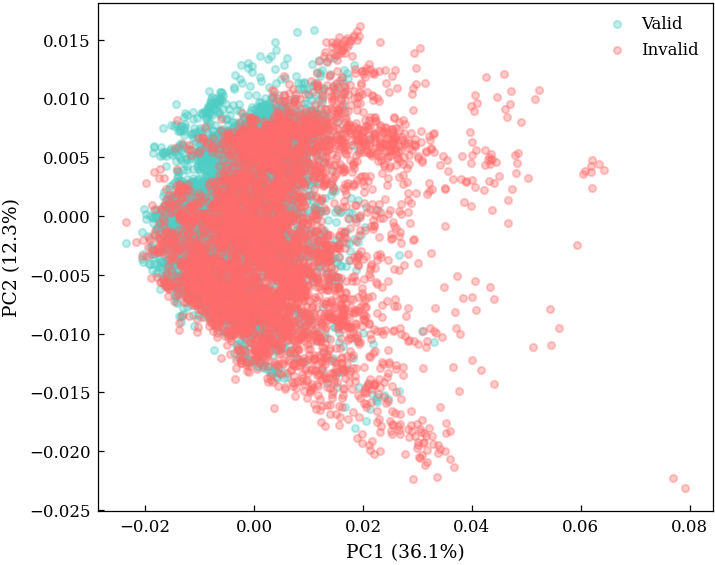

In [79]:
X_best = head_datasets[(best_l, best_h)]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_best)

fig, ax = plt.subplots(figsize=(5, 4))
for val, label_str, color in [(True, 'Valid', '#4ECDC4'), (False, 'Invalid', '#FF6B6B')]:
    mask = labels == val
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, alpha=0.35, s=12, label=label_str)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend()
fig.tight_layout()
#fig.savefig(FIGURES_DIR / 'probe_single_head_pca.pdf', bbox_inches='tight')

## 2. Attention Head Probe: greedy-selection

Sequentially add the attention head that maximally improves probe accuracy.
Iteration 1 reuses the single-head CV scores computed above.
Subsequent iterations evaluate each remaining head concatenated to the
current selected feature set.

In [ ]:
iteration_history = []
selected_heads = []
combined_X_cv = None   # growing feature matrix restricted to the CV pool
remaining = [(l, h) for l in range(n_layers) for h in range(n_heads)]

print(f'GREEDY FORWARD HEAD SELECTION  k={TOP_K}\n' + '=' * 60)

for iteration in range(TOP_K):
    print(f'\n--- Iteration {iteration + 1} ---')

    auroc_matrix = np.full((n_layers, n_heads), np.nan)
    f1_matrix = np.full((n_layers, n_heads), np.nan)
    fold_per_head = {}
    oof_per_head = {}

    for (l, h) in remaining:
        X_head_cv = head_datasets[(l, h)][cv_idx]
        X_cand = X_head_cv if combined_X_cv is None \
                    else np.concatenate([combined_X_cv, X_head_cv], axis=1)

        # Evaluate with fresh cv_score
        (_, _,
         mean_auroc, fold_aurocs,
         mean_f1,    fold_f1s,
         oof_probs) = cv_score(attention_probe, X_cand, labels_cv, kfold_cv)

        auroc_matrix[l, h] = mean_auroc
        f1_matrix[l, h] = mean_f1
        fold_per_head[(l, h)] = {'auroc': fold_aurocs, 'f1': fold_f1s}
        oof_per_head[(l, h)] = oof_probs

    # Select by F1
    valid_heads = [(l, h) for (l, h) in remaining if not np.isnan(f1_matrix[l, h])]
    best_lh = max(valid_heads, key=lambda k: f1_matrix[k])
    bl, bh = best_lh
    best_auroc = float(auroc_matrix[bl, bh])
    best_f1 = float(f1_matrix[bl, bh])
    print(f'  Selected: layer={bl:2d}, head={bh:2d}  AUROC={best_auroc:.4f}  F1={best_f1:.4f}')

    # Mask previously selected heads for visualisation
    vis_auroc = auroc_matrix.copy()
    vis_f1 = f1_matrix.copy()
    for sl, sh in selected_heads:
        vis_auroc[sl, sh] = np.nan
        vis_f1[sl, sh] = np.nan

    # Update state
    X_best_head_cv = head_datasets[best_lh][cv_idx]
    combined_X_cv = (X_best_head_cv.copy() if combined_X_cv is None
                      else np.concatenate([combined_X_cv, X_best_head_cv], axis=1))
    remaining.remove(best_lh)
    selected_heads.append(best_lh)

    iteration_history.append({
        'iteration':         iteration + 1,
        'selected_layer':    bl,
        'selected_head':     bh,
        'marginal_auroc':    best_auroc,
        'marginal_f1':       best_f1,
        'fold_aurocs':       fold_per_head[best_lh]['auroc'],
        'fold_f1s':          fold_per_head[best_lh]['f1'],
        'head_auroc_matrix': vis_auroc,
        'head_f1_matrix':    vis_f1,
        'combined_features': combined_X_cv.copy(),
        'oof_probs':         oof_per_head[best_lh],
        'oof_labels':        labels_cv.copy(),
    })

print('\nDone.')

GREEDY FORWARD HEAD SELECTION  k=5

--- Iteration 1 ---
  Selected: layer=16, head=11  AUROC=0.8268  F1=0.7853

--- Iteration 2 ---
  Selected: layer=15, head=12  AUROC=0.8532  F1=0.8101

--- Iteration 3 ---


In [85]:
iteration_history

[{'iteration': 1,
  'selected_layer': 16,
  'selected_head': 11,
  'marginal_auroc': 0.8268085311144855,
  'marginal_f1': 0.785255337612021,
  'fold_aurocs': [0.8441073541862273,
   0.8276142623954295,
   0.8038873914923231,
   0.7900013804647822,
   0.8684322670336656],
  'fold_f1s': [0.7761786600496278,
   0.7940754897276636,
   0.8662131519274378,
   0.6655309483248155,
   0.8242784380305603],
  'head_auroc_matrix': array([[0.73189717, 0.70951   , 0.63558811, ..., 0.60709359, 0.65857964,
          0.42157464],
         [0.70145886, 0.59150192, 0.66140795, ..., 0.70040341, 0.73152134,
          0.71636865],
         [0.62738587, 0.59993162, 0.6745468 , ..., 0.72735612, 0.63133162,
          0.5995529 ],
         ...,
         [0.71686624, 0.73994379, 0.72076594, ..., 0.76484988, 0.78034095,
          0.72983745],
         [0.75554461, 0.78028608, 0.75669663, ..., 0.669145  , 0.65945836,
          0.77503634],
         [0.74559889, 0.79221674, 0.79357995, ..., 0.75191807, 0.75990193,


In [ ]:
iteration_history

### Visualisation 1 — Head Accuracy Heatmaps per Iteration

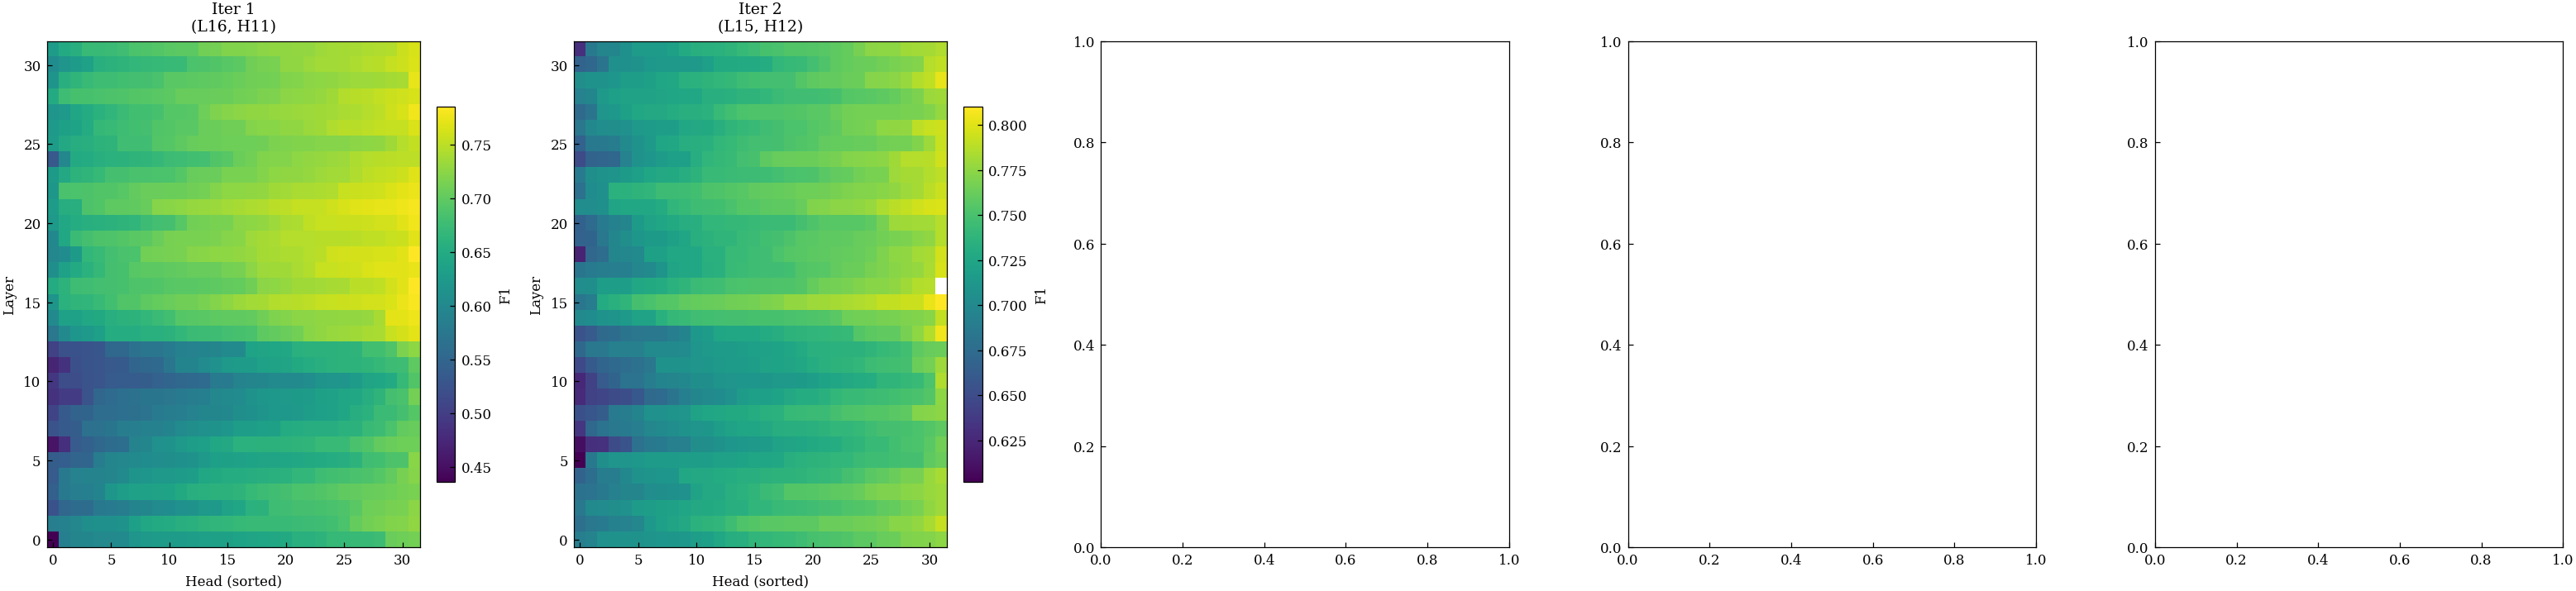

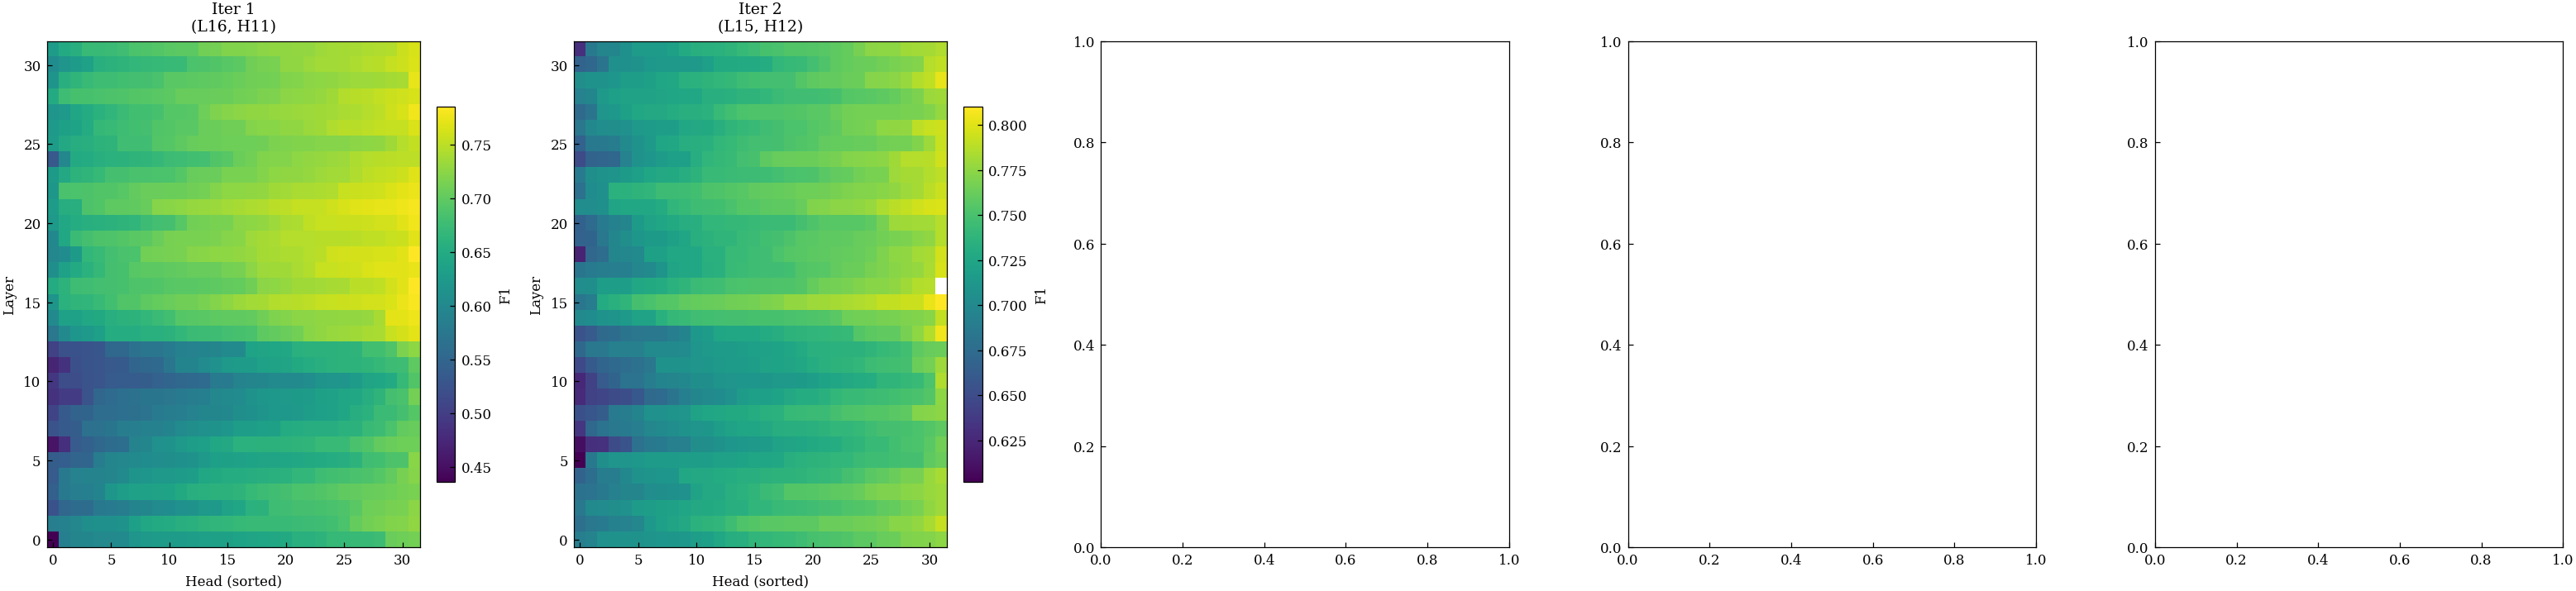

In [86]:
fig, axes = plt.subplots(1, TOP_K, figsize=(TOP_K * 4.2, 5))
if TOP_K == 1:
    axes = [axes]

for i, data in enumerate(iteration_history):
    ax = axes[i]
    mat = data['head_f1_matrix'].copy()

    sorted_mat = np.sort(mat, axis=1)
    vmin, vmax = np.nanmin(sorted_mat), np.nanmax(sorted_mat)
    im = ax.imshow(sorted_mat, cmap='viridis', aspect='auto', origin='lower',
                   vmin=vmin, vmax=vmax)
    bl, bh = data['selected_layer'], data['selected_head']
    ax.set_title(f'Iter {i + 1}\n(L{bl}, H{bh})', fontsize=9)
    ax.set_xlabel('Head (sorted)', fontsize=8)
    ax.set_ylabel('Layer', fontsize=8)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('F1', fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR + f'probe_greedy_heatmaps_{DATASET}_e-{EXTRACTION_MODEL}_j-{JUDGE_MODEL}.pdf', bbox_inches='tight')
fig

### Visualisation 2 — AUROC and F1 Progression

In [ ]:
iters       = np.arange(1, TOP_K + 1)
mean_aurocs = [d['marginal_auroc'] for d in iteration_history]
std_aurocs  = [np.std(d['fold_aurocs']) for d in iteration_history]
mean_f1s    = [d['marginal_f1'] for d in iteration_history]
std_f1s     = [np.std(d['fold_f1s']) for d in iteration_history]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, means, stds, ylabel, color, best_single in [
    (axes[0], mean_aurocs, std_aurocs, 'CV AUROC', '#1b6ca8',
     head_scores_auroc[best_l, best_h]),
    (axes[1], mean_f1s,    std_f1s,    'CV F1',    '#2ca87f',
     head_scores_f1[best_l, best_h]),
]:
    ax.plot(iters, means, 'o-', lw=2, ms=7, color=color, label='Greedy selection')
    ax.fill_between(iters,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    alpha=0.2, color=color)
    ax.axhline(best_single, ls='--', color='gray', label='Best single head')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Greedy selection — {ylabel}')
    ax.set_xticks(iters)
    ax.legend()
    ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'probe_greedy_metric_progression.pdf', bbox_inches='tight')
fig

In [ ]:
iteration_history = []
selected_heads = []
combined_X_cv = None   # growing feature matrix restricted to the CV pool
remaining = [(l, h) for l in range(n_layers) for h in range(n_heads)]

print(f'GREEDY FORWARD HEAD SELECTION  k={TOP_K}\n' + '=' * 60)

for iteration in range(TOP_K):
    print(f'\n--- Iteration {iteration + 1} ---')

    auroc_matrix = np.full((n_layers, n_heads), np.nan)
    f1_matrix = np.full((n_layers, n_heads), np.nan)
    fold_per_head = {}
    oof_per_head = {}

    for (l, h) in remaining:
        X_head_cv = head_datasets[(l, h)][cv_idx]
        X_cand = X_head_cv if combined_X_cv is None \
                    else np.concatenate([combined_X_cv, X_head_cv], axis=1)

        # Evaluate with fresh cv_score
        (_, _,
         mean_auroc, fold_aurocs,
         mean_f1,    fold_f1s,
         oof_probs) = cv_score(attention_probe, X_cand, labels_cv, kfold_cv)

        auroc_matrix[l, h] = mean_auroc
        f1_matrix[l, h] = mean_f1
        fold_per_head[(l, h)] = {'auroc': fold_aurocs, 'f1': fold_f1s}
        oof_per_head[(l, h)] = oof_probs

    # Select by F1
    valid_heads = [(l, h) for (l, h) in remaining if not np.isnan(f1_matrix[l, h])]
    best_lh = max(valid_heads, key=lambda k: f1_matrix[k])
    bl, bh = best_lh
    best_auroc = float(auroc_matrix[bl, bh])
    best_f1 = float(f1_matrix[bl, bh])
    print(f'  Selected: layer={bl:2d}, head={bh:2d}  AUROC={best_auroc:.4f}  F1={best_f1:.4f}')

    # Mask previously selected heads for visualisation
    vis_auroc = auroc_matrix.copy()
    vis_f1 = f1_matrix.copy()
    for sl, sh in selected_heads:
        vis_auroc[sl, sh] = np.nan
        vis_f1[sl, sh] = np.nan

    # Update state
    X_best_head_cv = head_datasets[best_lh][cv_idx]
    combined_X_cv = (X_best_head_cv.copy() if combined_X_cv is None
                      else np.concatenate([combined_X_cv, X_best_head_cv], axis=1))
    remaining.remove(best_lh)
    selected_heads.append(best_lh)

    iteration_history.append({
        'iteration':         iteration + 1,
        'selected_layer':    bl,
        'selected_head':     bh,
        'marginal_auroc':    best_auroc,
        'marginal_f1':       best_f1,
        'fold_aurocs':       fold_per_head[best_lh]['auroc'],
        'fold_f1s':          fold_per_head[best_lh]['f1'],
        'head_auroc_matrix': vis_auroc,
        'head_f1_matrix':    vis_f1,
        'combined_features': combined_X_cv.copy(),
        'oof_probs':         oof_per_head[best_lh],
        'oof_labels':        labels_cv.copy(),
    })

print('\nDone.')

### Visualisation 3 — Per-Fold AUROC and F1 by Iteration

In [ ]:
auroc_fold_data = np.array([d['fold_aurocs'] for d in iteration_history])  # (TOP_K, N_FOLDS)
f1_fold_data    = np.array([d['fold_f1s']    for d in iteration_history])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fold_labels = [f'F{i}' for i in range(N_FOLDS)]
iter_labels = [f'Iter {i + 1}' for i in range(TOP_K)]

for ax, data, title, cmap in [
    (axes[0], auroc_fold_data, 'AUROC per fold', 'plasma'),
    (axes[1], f1_fold_data,    'F1 per fold',    'viridis'),
]:
    vmin, vmax = data.min() - 0.01, data.max()
    im = ax.imshow(data, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(N_FOLDS))
    ax.set_xticklabels(fold_labels)
    ax.set_yticks(range(TOP_K))
    ax.set_yticklabels(iter_labels)
    ax.set_xlabel('Fold')
    ax.set_title(title)
    for i in range(TOP_K):
        for j in range(N_FOLDS):
            ax.text(j, i, f'{data[i, j]:.3f}', ha='center', va='center',
                    fontsize=7, color='black')
    plt.colorbar(im, ax=ax)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'probe_greedy_fold_metrics.pdf', bbox_inches='tight')
fig

### Visualisation 4 — PCA of Combined Features per Iteration

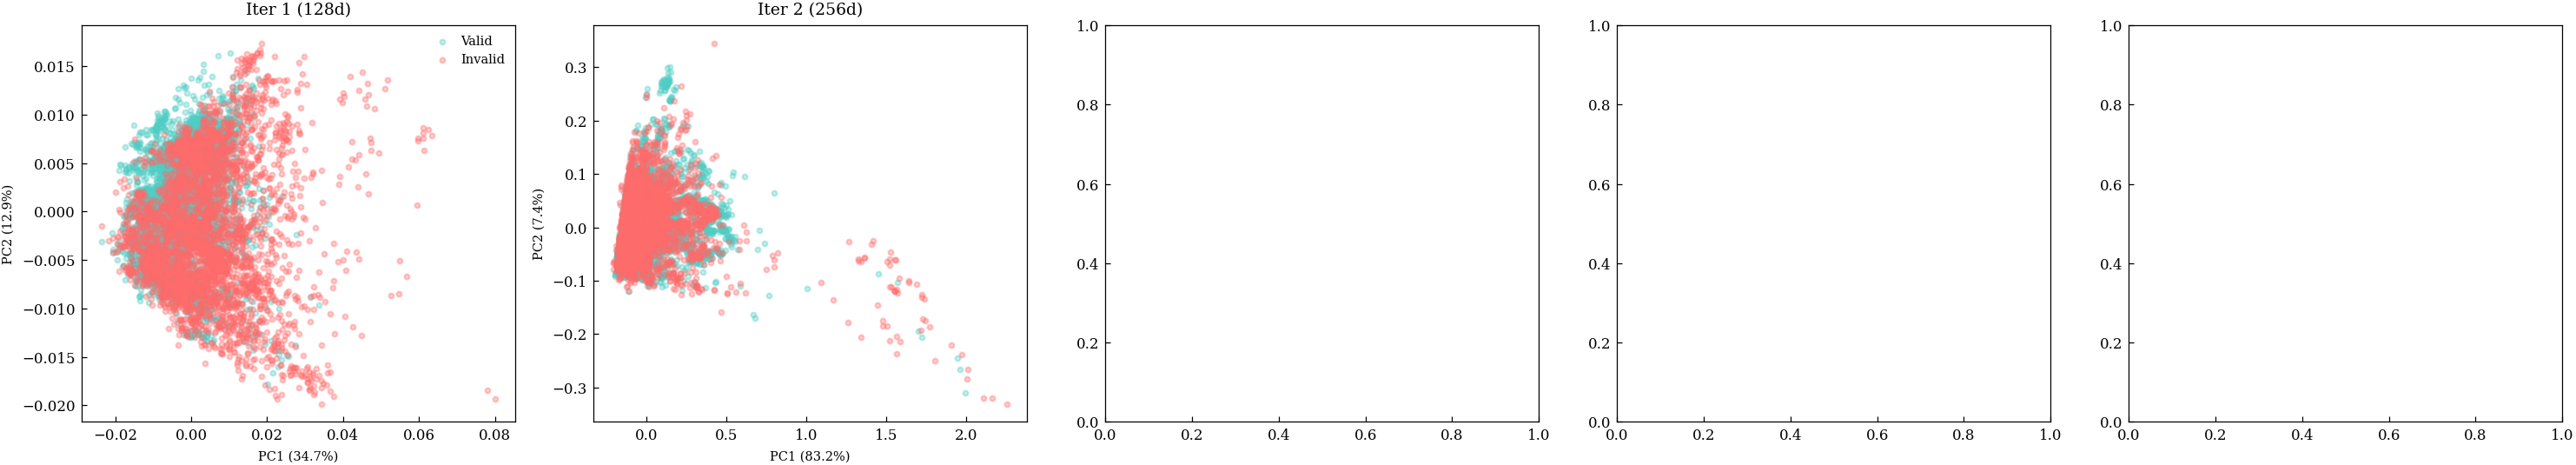

In [87]:
fig, axes = plt.subplots(1, TOP_K, figsize=(TOP_K * 4, 3.8))
if TOP_K == 1:
    axes = [axes]

for i, data in enumerate(iteration_history):
    ax = axes[i]
    X_combined = data['combined_features']
    true_labels = data['oof_labels']

    pca_i = PCA(n_components=2)
    Xp = pca_i.fit_transform(X_combined)

    for val, lbl, color in [(True, 'Valid', '#4ECDC4'), (False, 'Invalid', '#FF6B6B')]:
        mask = true_labels == val
        ax.scatter(Xp[mask, 0], Xp[mask, 1], c=color, alpha=0.35, s=8, label=lbl)

    dims = X_combined.shape[1]
    ax.set_title(f'Iter {i + 1} ({dims}d)', fontsize=9)
    ax.set_xlabel(f'PC1 ({pca_i.explained_variance_ratio_[0]:.1%})', fontsize=7)
    ax.set_ylabel(f'PC2 ({pca_i.explained_variance_ratio_[1]:.1%})', fontsize=7)
    if i == 0:
        ax.legend(fontsize=7)

fig.tight_layout()
#fig.savefig(FIGURES_DIR / 'probe_greedy_pca.pdf', bbox_inches='tight')
#fig

### Visualisation 5 — Calibration Curves per Iteration

In [ ]:
colors_iter = plt.cm.tab10(np.linspace(0, 0.9, TOP_K))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect calibration')

for i, data in enumerate(iteration_history):
    diag = reliability_diagram_data(data['oof_probs'], data['oof_labels'])
    valid = ~np.isnan(diag['bin_accuracy'])
    ax.plot(
        diag['bin_centers'][valid],
        diag['bin_accuracy'][valid],
        'o-', color=colors_iter[i], lw=1.8, ms=5,
        label=f"Iter {i + 1} (ECE={diag['ece']:.3f})",
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed frequency')
ax.set_title('Calibration curves — iterative head selection')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'probe_greedy_calibration.pdf', bbox_inches='tight')
fig

### Visualisation 6 — Probability Distributions (Final Iteration)

In [ ]:
final = iteration_history[-1]
_df_final = pd.DataFrame({'prob': final['oof_probs'], 'label': final['oof_labels']})
fig = probability_distribution(_df_final, prob_col='prob', label_col='label')
fig.axes[0].set_title(f'Predicted probability — {TOP_K}-head ensemble')
fig.savefig(FIGURES_DIR / 'probe_greedy_prob_dist.pdf', bbox_inches='tight')
fig

### Summary

In [ ]:
print('=' * 68)
print('GREEDY SELECTION SUMMARY')
print('=' * 68)
for data in iteration_history:
    bl   = data['selected_layer']
    bh   = data['selected_head']
    std_a = np.std(data['fold_aurocs'])
    std_f = np.std(data['fold_f1s'])
    print(f"  Iter {data['iteration']}: L{bl:2d} H{bh:2d}  "
          f"AUROC={data['marginal_auroc']:.4f}+/-{std_a:.4f}  "
          f"F1={data['marginal_f1']:.4f}+/-{std_f:.4f}")

print()
print('=' * 68)
print('CV OUT-OF-FOLD METRICS BY ITERATION  (threshold=0.5)')
print('=' * 68)
print(f'{"Iter":>4}  {"Accuracy":>8}  {"Precision":>9}  {"Recall":>6}  {"F1":>6}  {"AUROC":>6}  ECE')

for data in iteration_history:
    probs = data['oof_probs']
    yl    = data['oof_labels']
    preds = probs > 0.5
    tp_ = int(( preds &  yl).sum())
    tn_ = int((~preds & ~yl).sum())
    fp_ = int(( preds & ~yl).sum())
    fn_ = int((~preds &  yl).sum())
    n_  = len(yl)
    acc_   = (tp_ + tn_) / n_
    prec_  = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else float('nan')
    rec_   = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else float('nan')
    f1_    = 2 * prec_ * rec_ / (prec_ + rec_) if (prec_ + rec_) > 0 else float('nan')
    auroc_ = roc_auc_score(yl, probs) if yl.sum() > 0 and (~yl).sum() > 0 else float('nan')
    diag   = reliability_diagram_data(probs, yl)
    print(f"  {data['iteration']:>2d}   {acc_:>8.4f}  {prec_:>9.4f}  "
          f"{rec_:>6.4f}  {f1_:>6.4f}  {auroc_:>6.4f}  {diag['ece']:.4f}")

### Final Multi-Head Probe

Train on the full CV pool using the greedy-selected head set, re-calibrate with Platt scaling, evaluate on the held-out test set.

In [ ]:
# ── Final Multi-Head Probe: Training + Platt Scaling + Test Evaluation ────────

def _build_combined(idx_set):
    """Reconstruct the combined feature matrix for a given index set."""
    return np.concatenate([head_datasets[lh][idx_set] for lh in selected_heads], axis=1)

X_cv_m   = combined_X_cv            # already restricted to cv_idx
X_cal_m  = _build_combined(cal_idx)
X_test_m = _build_combined(test_idx)
y_cv_m, y_cal_m, y_test_m = labels[cv_idx], labels[cal_idx], labels[test_idx]

n_selected = len(selected_heads)
head_labels = [f'L{l}H{h}' for l, h in selected_heads]

# Train final multi-head probe
final_probe_multi = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0, class_weight='balanced', solver='lbfgs',
        max_iter=1000, random_state=42,
    ))
]).fit(X_cv_m, y_cv_m)

# Platt scaling
raw_cal_m = final_probe_multi.predict_proba(X_cal_m)[:, 1].reshape(-1, 1)
platt_multi = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000).fit(raw_cal_m, y_cal_m)

# Test-set probabilities
raw_test_m = final_probe_multi.predict_proba(X_test_m)[:, 1]
cal_test_m = platt_multi.predict_proba(raw_test_m.reshape(-1, 1))[:, 1]

print(f'=== Final {n_selected}-head probe {head_labels} — test set ===\n')
_probe_metrics(raw_test_m, y_test_m, 'Uncalibrated')
print()
_probe_metrics(cal_test_m, y_test_m, 'Platt-calibrated')

# Calibration curves
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect')
for probs, label, color in [
    (raw_test_m, 'Uncalibrated',     '#e07b39'),
    (cal_test_m, 'Platt-calibrated', '#3984e0'),
]:
    d = reliability_diagram_data(probs, y_test_m)
    valid = ~np.isnan(d['bin_accuracy'])
    ax.plot(d['bin_centers'][valid], d['bin_accuracy'][valid], 'o-',
            color=color, lw=1.8, ms=5, label=f"{label} (ECE={d['ece']:.3f})")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed frequency')
ax.set_title(f'Calibration — final {n_selected}-head probe')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'probe_final_multi_calibration.pdf', bbox_inches='tight')
fig

## 3. Layer Output Probe

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
layers_x = np.arange(n_layers_lo)

for ax, score_vec, fold_dict, title, color in [
    (axes[0], layer_scores_auroc, layer_fold_aurocs, 'AUROC',    '#1b6ca8'),
    (axes[1], layer_scores_f1,    layer_fold_f1s,    'F1',       '#2ca87f'),
    (axes[2], layer_scores_acc,   layer_fold_accs,   'Accuracy', '#e07b39'),
]:
    stds = np.array([np.std(fold_dict[l]) for l in range(n_layers_lo)])
    ax.errorbar(layers_x, score_vec, yerr=stds, fmt='o-', lw=2, ms=6, 
                color=color, capsize=4, alpha=0.8)
    ax.set_xlabel('Layer')
    ax.set_ylabel(title)
    ax.set_title(f'Single-layer probe — {title}\n(layer outputs, ±1 std)')
    ax.grid(alpha=0.3)
    ax.set_xticks(layers_x)

fig.tight_layout()